# HR Employee Attrition Prediction
### Machine Learning for Management (MLAM) 

---

**Business Problem:**  
Employee attrition is costly. Replacing one employee can cost 50–200% of their annual salary.
This project uses Machine Learning to help HR managers **identify employees who are at risk of resigning**,
so that proactive retention actions can be taken.

**Dataset:** HR_DATA_MLAL.csv | 100,000 employees | 20 columns  
**Target Variable:** `Resigned` (0 = Stayed, 1 = Resigned)  
**Class Imbalance:** ~90% stayed vs ~10% resigned

---

**Project Workflow:**
1. Install and Import Libraries
2. Load and Inspect the Data
3. Data Cleaning
4. Exploratory Data Analysis (EDA)
5. Correlation Analysis
6. Encoding Categorical Variables
7. Train-Test Split
8. Handling Class Imbalance with SMOTE
9. Model 1 — Logistic Regression
10. Model 2 — Random Forest
11. Model 3 — Gradient Boosting 
12. Model Comparison (all 3 models)
13. Threshold Adjustment
14. Feature Importance
15. Business Interpretation and Recommendations


---
## Step 1: Install and Import Libraries

In [ ]:
# Install the imbalanced-learn library for SMOTE (run once)
!pip install imbalanced-learn --quiet

In [1]:
# Import all required libraries
# We use only the libraries permitted by the course

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn: splitting, scaling, models, evaluation
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# SMOTE for handling class imbalance
from imblearn.over_sampling import SMOTE

# Plot settings
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110

print('All libraries imported successfully.')


All libraries imported successfully.


---
## Step 2: Load and Inspect the Data

In [3]:
# Load the dataset
# Update the file path if your CSV is stored in a different location
df = pd.read_csv('HR DATA_MLAL.csv')

# Convert the target variable from boolean to integer (0 and 1)
df['Resigned'] = df['Resigned'].astype(int)

# View first few rows
print(f'Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head()

Dataset shape: 100,000 rows × 20 columns


,Employee_ID,Department,Gender,Age,Job_Title,Hire_Date,Years_At_Company,Education_Level,Performance_Score,Monthly_Salary,Work_Hours_Per_Week,Projects_Handled,Overtime_Hours,Sick_Days,Remote_Work_Frequency,Team_Size,Training_Hours,Promotions,Employee_Satisfaction_Score,Resigned
0,1,IT,Male,55,Specialist,03:05.6,2,High School,5,6750,33,32,22,2,0,14,66,0,2.63,0
1,2,Finance,Male,29,Developer,03:05.6,0,High School,5,7500,34,34,13,14,100,12,61,2,1.72,0
2,3,Finance,Male,55,Specialist,03:05.6,8,High School,3,5850,37,27,6,3,50,10,1,0,3.17,0
3,4,Customer Support,Female,48,Analyst,03:05.6,7,Bachelor,2,4800,52,10,28,12,100,10,0,1,1.86,0
4,5,Engineering,Female,36,Analyst,03:05.6,3,Bachelor,2,4800,38,11,29,13,100,15,9,1,1.25,0


In [4]:
# Check data types for each column
print('Column names and data types:')
print(df.dtypes)

Column names and data types:
Employee_ID                      int64
Department                      object
Gender                          object
Age                              int64
Job_Title                       object
Hire_Date                       object
Years_At_Company                 int64
Education_Level                 object
Performance_Score                int64
Monthly_Salary                   int64
Work_Hours_Per_Week              int64
Projects_Handled                 int64
Overtime_Hours                   int64
Sick_Days                        int64
Remote_Work_Frequency            int64
Team_Size                        int64
Training_Hours                   int64
Promotions                       int64
Employee_Satisfaction_Score    float64
Resigned                         int64
dtype: object


In [5]:
# Check for missing values
print('Missing values per column:')
print(df.isnull().sum())

Missing values per column:
Employee_ID                    0
Department                     0
Gender                         0
Age                            0
Job_Title                      0
Hire_Date                      0
Years_At_Company               0
Education_Level                0
Performance_Score              0
Monthly_Salary                 0
Work_Hours_Per_Week            0
Projects_Handled               0
Overtime_Hours                 0
Sick_Days                      0
Remote_Work_Frequency          0
Team_Size                      0
Training_Hours                 0
Promotions                     0
Employee_Satisfaction_Score    0
Resigned                       0
dtype: int64


In [6]:
# Check the target variable distribution
# This shows how many employees resigned vs stayed
print('Target variable — Resigned:')
vc = df['Resigned'].value_counts()
print(f'  Stayed   (0): {vc[0]:,}  ({vc[0]/len(df)*100:.1f}%)')
print(f'  Resigned (1): {vc[1]:,}  ({vc[1]/len(df)*100:.1f}%)')
print()
print('Observation: The dataset is imbalanced — only ~10% of employees resigned.')
print('This means a model that always predicts "Stayed" would still get 90% accuracy.')
print('We must use SMOTE and focus on Recall, not just Accuracy.')

Target variable — Resigned:
  Stayed   (0): 89,990  (90.0%)
  Resigned (1): 10,010  (10.0%)

Observation: The dataset is imbalanced — only ~10% of employees resigned.
This means a model that always predicts "Stayed" would still get 90% accuracy.
We must use SMOTE and focus on Recall, not just Accuracy.


---
## Step 3: Data Cleaning

In [7]:
# ----- 3.1 Drop Employee_ID -----
# Employee_ID is just an identification number.
# It has no relationship to resignation and should never be used as a predictor.

df.drop(columns=['Employee_ID'], inplace=True)
print('Employee_ID dropped.')

Employee_ID dropped.


In [8]:
# ----- 3.2 Handle Hire_Date -----
# Check what values Hire_Date contains

print(f'Unique values in Hire_Date: {df["Hire_Date"].nunique()}')
print(f'Sample value: {df["Hire_Date"].unique()[:3]}')
print()
print('Observation: Hire_Date contains only one unique value ("03:05.6").')
print('This appears to be a corrupted Excel timestamp — it carries no useful information.')
print('Additionally, the column Years_At_Company already captures employee tenure.')
print('Decision: Drop Hire_Date.')

Unique values in Hire_Date: 1
Sample value: ['03:05.6']

Observation: Hire_Date contains only one unique value ("03:05.6").
This appears to be a corrupted Excel timestamp — it carries no useful information.
Additionally, the column Years_At_Company already captures employee tenure.
Decision: Drop Hire_Date.


In [9]:
# Drop the corrupted Hire_Date column
df.drop(columns=['Hire_Date'], inplace=True)
print('Hire_Date dropped.')
print(f'Remaining columns ({df.shape[1]}): {list(df.columns)}')

Hire_Date dropped.
Remaining columns (18): ['Department', 'Gender', 'Age', 'Job_Title', 'Years_At_Company', 'Education_Level', 'Performance_Score', 'Monthly_Salary', 'Work_Hours_Per_Week', 'Projects_Handled', 'Overtime_Hours', 'Sick_Days', 'Remote_Work_Frequency', 'Team_Size', 'Training_Hours', 'Promotions', 'Employee_Satisfaction_Score', 'Resigned']


In [10]:
# ----- 3.3 Remove Duplicate Rows -----
n_dup = df.duplicated().sum()
print(f'Duplicate rows found: {n_dup}')

if n_dup > 0:
    df.drop_duplicates(inplace=True)
    print(f'Duplicates removed. New shape: {df.shape}')
else:
    print('No duplicates found. Dataset is clean.')

Duplicate rows found: 0
No duplicates found. Dataset is clean.


In [11]:
# ----- 3.4 Summary Statistics After Cleaning -----
print(f'Final clean dataset: {df.shape[0]:,} rows × {df.shape[1]} columns')
print()
df.describe().round(2)

Final clean dataset: 100,000 rows × 18 columns



,Age,Years_At_Company,Performance_Score,Monthly_Salary,Work_Hours_Per_Week,Projects_Handled,Overtime_Hours,Sick_Days,Remote_Work_Frequency,Team_Size,Training_Hours,Promotions,Employee_Satisfaction_Score,Resigned
count,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.0
mean,41.03,4.48,3.00,6403.21,44.96,24.43,14.51,7.01,50.09,10.01,49.51,1.00,3.00,0.1
std,11.24,2.87,1.41,1372.51,8.94,14.47,8.66,4.33,35.35,5.50,28.89,0.82,1.15,0.3
min,22.00,0.00,1.00,3850.00,30.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,1.00,0.0
25%,31.00,2.00,2.00,5250.00,37.00,12.00,7.00,3.00,25.00,5.00,25.00,0.00,2.01,0.0
50%,41.00,4.00,3.00,6500.00,45.00,24.00,15.00,7.00,50.00,10.00,49.00,1.00,3.00,0.0
75%,51.00,7.00,4.00,7500.00,53.00,37.00,22.00,11.00,75.00,15.00,75.00,2.00,3.99,0.0
max,60.00,10.00,5.00,9000.00,60.00,49.00,29.00,14.00,100.00,19.00,99.00,2.00,5.00,1.0


---
## Step 4: Exploratory Data Analysis (EDA)

We explore the data visually to understand patterns in the dataset before building models.

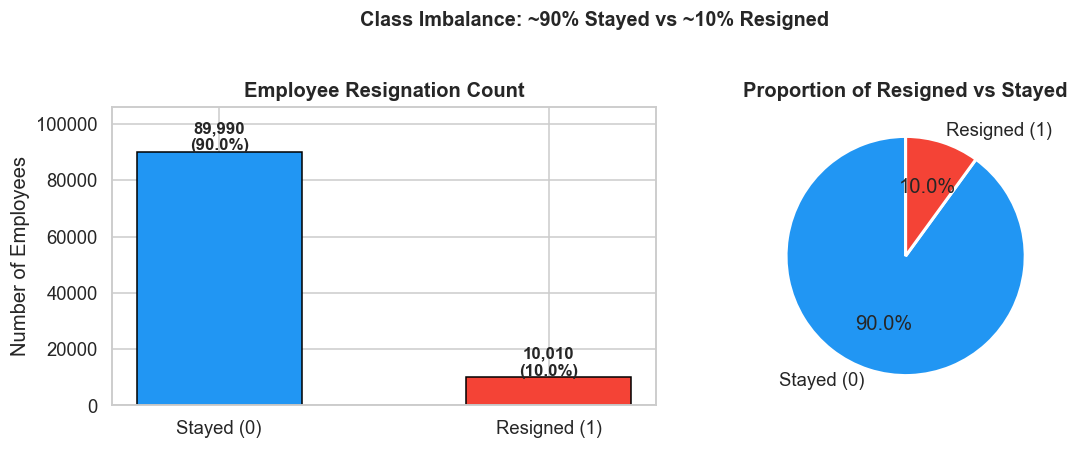

The dataset is highly imbalanced. We will use SMOTE to address this.


In [12]:
# ----- 4.1 Class Imbalance — Target Variable Distribution -----

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

vc = df['Resigned'].value_counts().reindex([0, 1])
labels = ['Stayed (0)', 'Resigned (1)']
colors = ['#2196F3', '#F44336']

# Bar chart
axes[0].bar(labels, vc.values, color=colors, edgecolor='black', width=0.5)
for i, v in enumerate(vc.values):
    axes[0].text(i, v + 600, f'{v:,}\n({v/len(df)*100:.1f}%)',
                 ha='center', fontweight='bold', fontsize=11)
axes[0].set_title('Employee Resignation Count', fontweight='bold')
axes[0].set_ylabel('Number of Employees')
axes[0].set_ylim(0, vc.max() * 1.18)

# Pie chart
axes[1].pie(vc.values, labels=labels, autopct='%1.1f%%',
            colors=colors, startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proportion of Resigned vs Stayed', fontweight='bold')

plt.suptitle('Class Imbalance: ~90% Stayed vs ~10% Resigned',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('The dataset is highly imbalanced. We will use SMOTE to address this.')

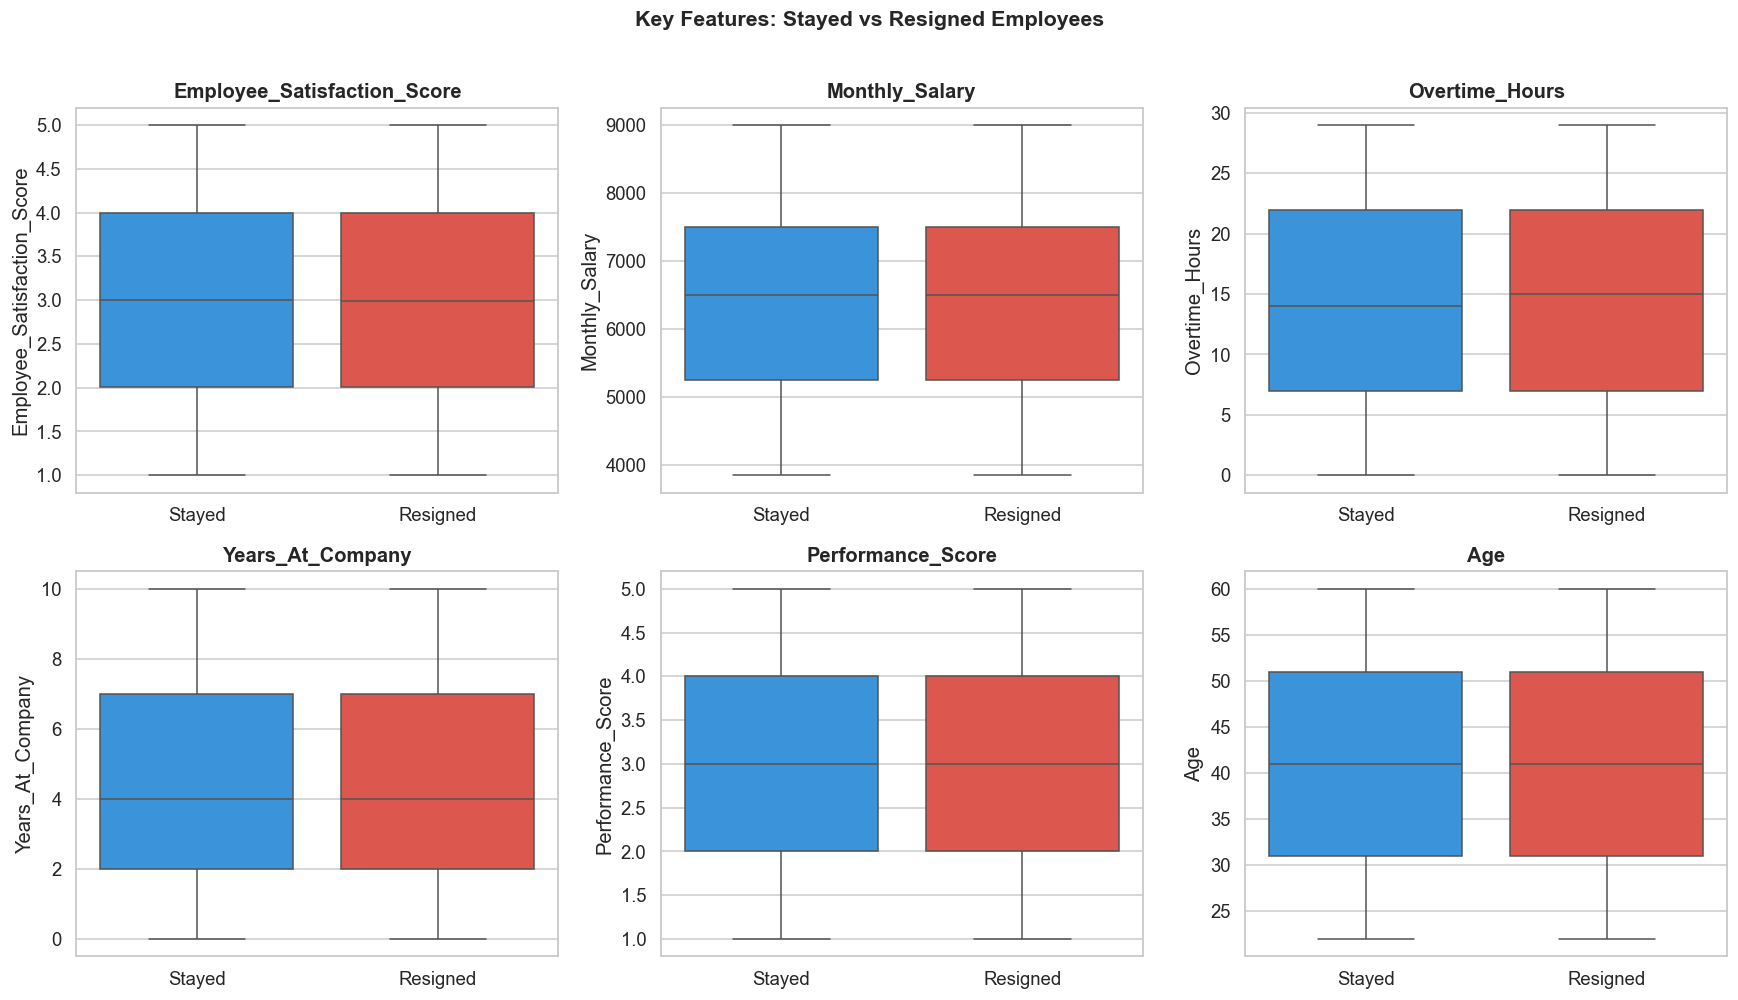

Average values — Stayed vs Resigned:
                             Stayed (0)  Resigned (1)
Employee_Satisfaction_Score        3.00          2.99
Monthly_Salary                  6403.91       6396.94
Overtime_Hours                    14.51         14.58
Years_At_Company                   4.48          4.48
Performance_Score                  3.00          2.98
Age                               41.02         41.15

Interpretation: Differences in means are modest.
No single feature clearly separates the two groups.
This is consistent with weak linear correlations (see Step 5).


In [13]:
# ----- 4.2 Key Numerical Features by Resignation Status -----
# Box plots help us see if resigned employees differ on key measures

# Create a label column for plotting (will be removed before modelling)
df['Status'] = df['Resigned'].map({0: 'Stayed', 1: 'Resigned'})

key_features = [
    'Employee_Satisfaction_Score', 'Monthly_Salary',
    'Overtime_Hours', 'Years_At_Company',
    'Performance_Score', 'Age'
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

palette = {'Stayed': '#2196F3', 'Resigned': '#F44336'}

for i, col in enumerate(key_features):
    sns.boxplot(
        data=df,
        x='Status',
        y=col,
        palette=palette,
        order=['Stayed', 'Resigned'],
        ax=axes[i]
    )
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel('')

plt.suptitle('Key Features: Stayed vs Resigned Employees',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Print mean comparison
print('Average values — Stayed vs Resigned:')
means = df.groupby('Resigned')[key_features].mean().round(2)
means.index = ['Stayed (0)', 'Resigned (1)']
print(means.T.to_string())
print()
print('Interpretation: Differences in means are modest.')
print('No single feature clearly separates the two groups.')
print('This is consistent with weak linear correlations (see Step 5).')

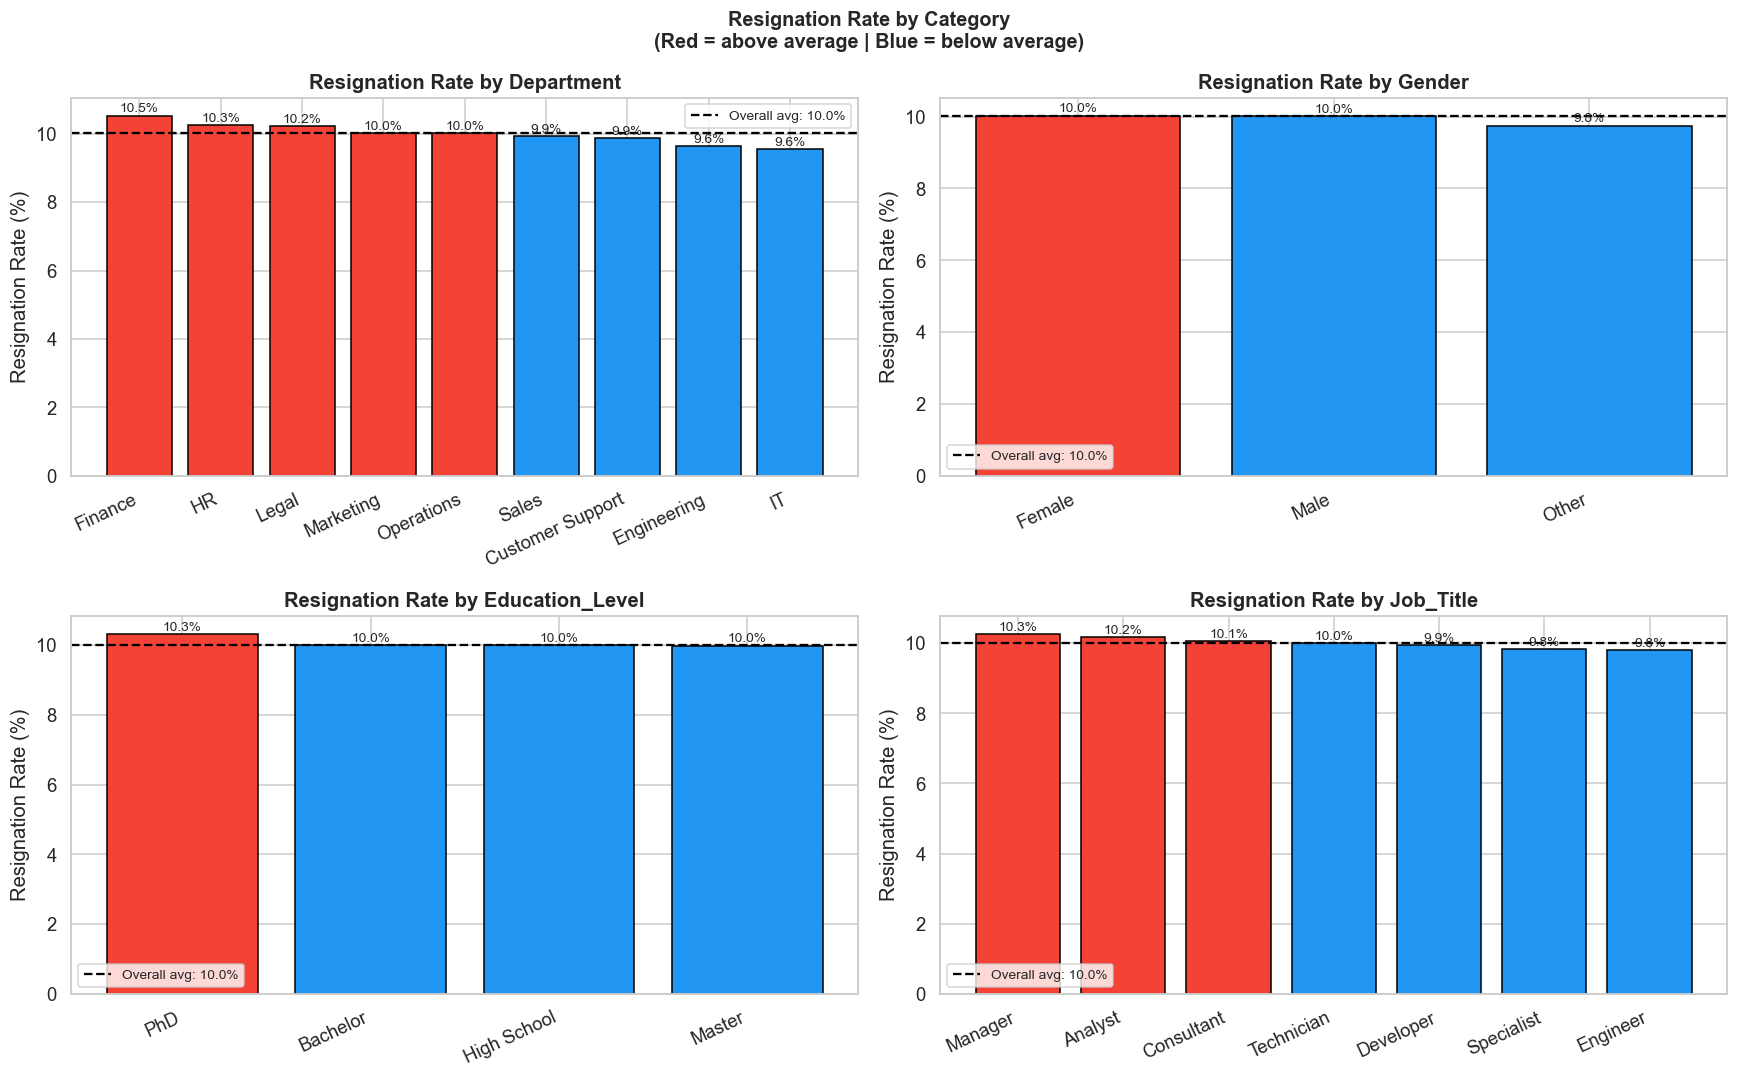

Overall resignation rate: 10.0%

Honest Interpretation:
Resignation rates are fairly evenly distributed across departments,
genders, education levels, and job titles. No single group stands out
dramatically. This suggests attrition is driven by individual-level
factors rather than structural differences between groups.


In [14]:
# ----- 4.3 Resignation Rate by Categorical Features -----
# Which departments, roles, or groups have higher resignation rates?

cat_cols = ['Department', 'Gender', 'Education_Level', 'Job_Title']
overall_rate = df['Resigned'].mean() * 100

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    rate = df.groupby(col)['Resigned'].mean().mul(100).sort_values(ascending=False)
    bar_colors = ['#F44336' if v > overall_rate else '#2196F3' for v in rate.values]

    axes[i].bar(rate.index, rate.values, color=bar_colors, edgecolor='black')
    axes[i].axhline(overall_rate, color='black', linestyle='--', linewidth=1.5,
                    label=f'Overall avg: {overall_rate:.1f}%')
    axes[i].set_title(f'Resignation Rate by {col}', fontweight='bold')
    axes[i].set_ylabel('Resignation Rate (%)')
    axes[i].set_xticklabels(rate.index, rotation=25, ha='right')
    axes[i].legend(fontsize=9)
    for j, v in enumerate(rate.values):
        axes[i].text(j, v + 0.1, f'{v:.1f}%', ha='center', fontsize=9)

plt.suptitle('Resignation Rate by Category\n(Red = above average | Blue = below average)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Overall resignation rate: {overall_rate:.1f}%')
print()
print('Honest Interpretation:')
print('Resignation rates are fairly evenly distributed across departments,')
print('genders, education levels, and job titles. No single group stands out')
print('dramatically. This suggests attrition is driven by individual-level')
print('factors rather than structural differences between groups.')

---
## Step 5: Correlation Analysis

We examine whether numerical features have a linear relationship with the target variable.

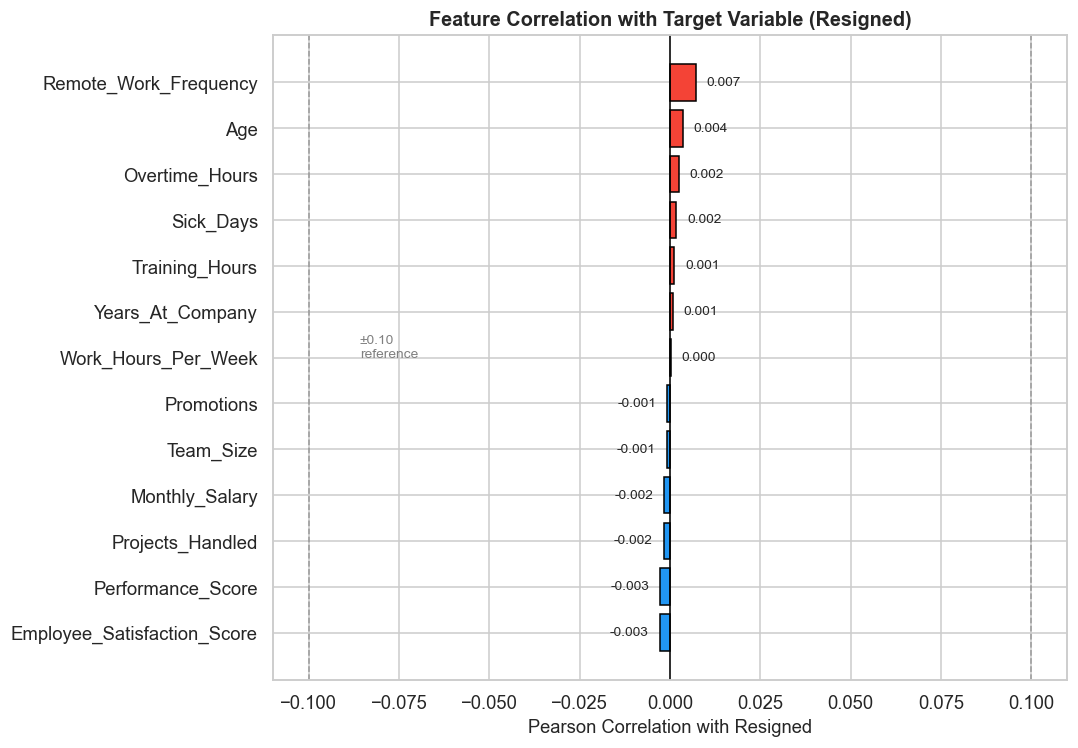

Honest Interpretation:
-------------------------------------------------------
All individual correlations with Resigned are weak (|r| < 0.10).

This means: no single feature strongly predicts resignation on its own.

Linear relationships are weak; patterns may be non-linear.
Tree-based models (like Random Forest) can detect combinations
of features that together signal risk — even when individual
correlations are low.


In [15]:
# ----- 5.1 Correlation with Target Variable -----
# We select only meaningful numerical columns (excluding ID and target)

num_cols = [
    'Age', 'Years_At_Company', 'Performance_Score', 'Monthly_Salary',
    'Work_Hours_Per_Week', 'Projects_Handled', 'Overtime_Hours',
    'Sick_Days', 'Remote_Work_Frequency', 'Team_Size',
    'Training_Hours', 'Promotions', 'Employee_Satisfaction_Score'
]

# Calculate correlation of each feature with the target
target_corr = df[num_cols + ['Resigned']].corr()['Resigned'].drop('Resigned')
target_corr = target_corr.sort_values()

# Plot
fig, ax = plt.subplots(figsize=(10, 7))
bar_colors = ['#F44336' if v > 0 else '#2196F3' for v in target_corr.values]
ax.barh(target_corr.index, target_corr.values, color=bar_colors, edgecolor='black')
ax.axvline(0, color='black', linewidth=1)
ax.axvline(0.10, color='grey', linestyle='--', linewidth=1, alpha=0.7)
ax.axvline(-0.10, color='grey', linestyle='--', linewidth=1, alpha=0.7)
ax.set_xlabel('Pearson Correlation with Resigned', fontsize=12)
ax.set_title('Feature Correlation with Target Variable (Resigned)',
             fontweight='bold', fontsize=13)
ax.text(0.11, 0.5, '±0.10\nreference',
        transform=ax.transAxes, color='grey', fontsize=9)

# Add value labels
for bar, val in zip(ax.patches, target_corr.values):
    offset = 0.003 if val >= 0 else -0.003
    ha = 'left' if val >= 0 else 'right'
    ax.text(val + offset, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', ha=ha, fontsize=9)

plt.tight_layout()
plt.show()

print('Honest Interpretation:')
print('-' * 55)
print('All individual correlations with Resigned are weak (|r| < 0.10).')
print()
print('This means: no single feature strongly predicts resignation on its own.')
print()
print('Linear relationships are weak; patterns may be non-linear.')
print('Tree-based models (like Random Forest) can detect combinations')
print('of features that together signal risk — even when individual')
print('correlations are low.')

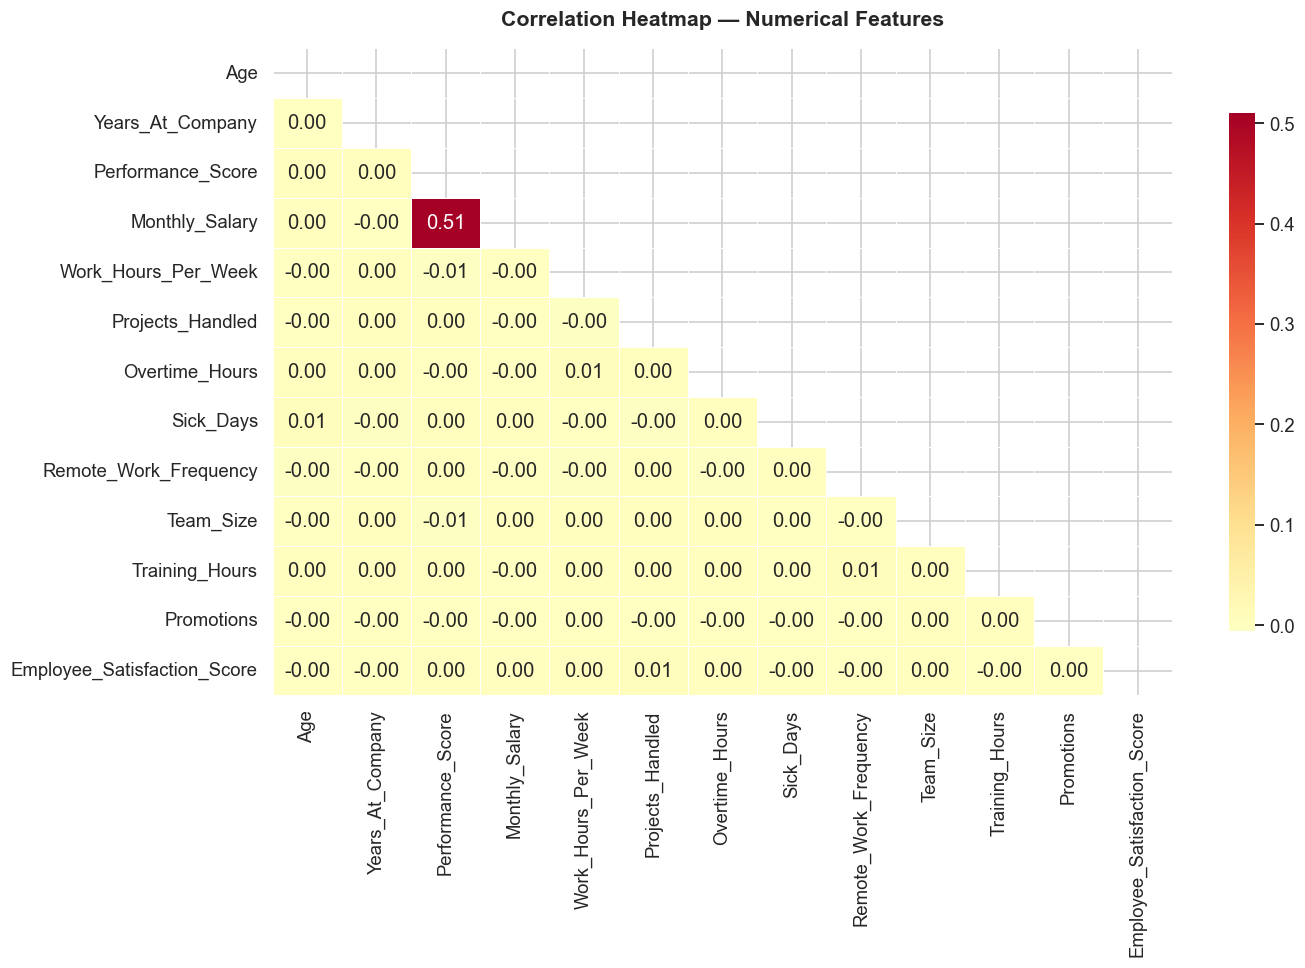

Note: Most inter-feature correlations are also weak.
Features are relatively independent, which is good for modelling.


In [16]:
# ----- 5.2 Heatmap of Correlations Among All Numerical Features -----

corr_matrix = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(13, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Show lower triangle only

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlBu_r',
    center=0,
    linewidths=0.4,
    ax=ax,
    cbar_kws={'shrink': 0.8}
)
ax.set_title('Correlation Heatmap — Numerical Features',
             fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

print('Note: Most inter-feature correlations are also weak.')
print('Features are relatively independent, which is good for modelling.')

---
## Step 6: Encoding Categorical Variables

> **Course Rule:** Use ONLY `pd.get_dummies(drop_first=True)`
> 
> **Why NOT LabelEncoder?**  
> LabelEncoder converts categories to numbers (e.g., Finance=0, IT=1, Marketing=2).  
> This implies Finance < IT < Marketing, which is **false** — categories have no natural order.  
> `get_dummies` creates a separate 0/1 column for each category, which is correct.

In [17]:
# Drop the Status helper column (used only for plotting)
df.drop(columns=['Status'], inplace=True, errors='ignore')

# Identify categorical columns
cat_cols = ['Department', 'Gender', 'Job_Title', 'Education_Level']
print(f'Categorical columns to encode: {cat_cols}')
print()

# Apply one-hot encoding
# drop_first=True removes one column per group to avoid multicollinearity
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# Convert any boolean dummy columns to integers (0/1)
for col in df_encoded.columns:
    if df_encoded[col].dtype == bool:
        df_encoded[col] = df_encoded[col].astype(int)

print(f'Shape before encoding: {df.shape}')
print(f'Shape after encoding:  {df_encoded.shape}')
print(f'\nNew columns created by encoding:')
new_cols = [c for c in df_encoded.columns if c not in df.columns]
print(new_cols)

Categorical columns to encode: ['Department', 'Gender', 'Job_Title', 'Education_Level']

Shape before encoding: (100000, 18)
Shape after encoding:  (100000, 33)

New columns created by encoding:
['Department_Engineering', 'Department_Finance', 'Department_HR', 'Department_IT', 'Department_Legal', 'Department_Marketing', 'Department_Operations', 'Department_Sales', 'Gender_Male', 'Gender_Other', 'Job_Title_Consultant', 'Job_Title_Developer', 'Job_Title_Engineer', 'Job_Title_Manager', 'Job_Title_Specialist', 'Job_Title_Technician', 'Education_Level_High School', 'Education_Level_Master', 'Education_Level_PhD']


---
## Step 7: Train-Test Split

We split the data into a **training set** (80%) and a **test set** (20%).  
`stratify=y` ensures both sets maintain the same 90:10 class ratio.

In [18]:
# Separate features (X) and target variable (y)
X = df_encoded.drop(columns=['Resigned'])
y = df_encoded['Resigned']

print(f'Features (X): {X.shape[0]:,} rows × {X.shape[1]} columns')
print(f'Target  (y): {y.shape[0]:,} values')
print()

# Stratified 80/20 split
# stratify=y ensures the same class ratio in train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y          # MANDATORY — preserves class ratio
)

print(f'Training set:  {X_train.shape[0]:,} rows')
print(f'Test set:      {X_test.shape[0]:,} rows')
print()
print('Class balance check:')
for name, y_split in [('Train', y_train), ('Test', y_test)]:
    vc = y_split.value_counts().reindex([0, 1])
    print(f'  {name}: Stayed={vc[0]:,} ({vc[0]/len(y_split)*100:.1f}%) '
          f'| Resigned={vc[1]:,} ({vc[1]/len(y_split)*100:.1f}%)')

Features (X): 100,000 rows × 32 columns
Target  (y): 100,000 values

Training set:  80,000 rows
Test set:      20,000 rows

Class balance check:
  Train: Stayed=71,992 (90.0%) | Resigned=8,008 (10.0%)
  Test: Stayed=17,998 (90.0%) | Resigned=2,002 (10.0%)


---
## Step 8: Handling Class Imbalance with SMOTE

**SMOTE** (Synthetic Minority Over-sampling Technique) creates artificial samples of the minority class
(Resigned employees) to balance the training set.

> **Important Rule:** SMOTE is applied **only on the training data**, AFTER the split.  
> The test set must stay as original real data. Applying SMOTE before splitting would be **data leakage**.

Before SMOTE (training set):
  Stayed   (0): 71,992
  Resigned (1): 8,008

After SMOTE (training set):
  Stayed   (0): 71,992
  Resigned (1): 71,992

Test set is unchanged (real data only).


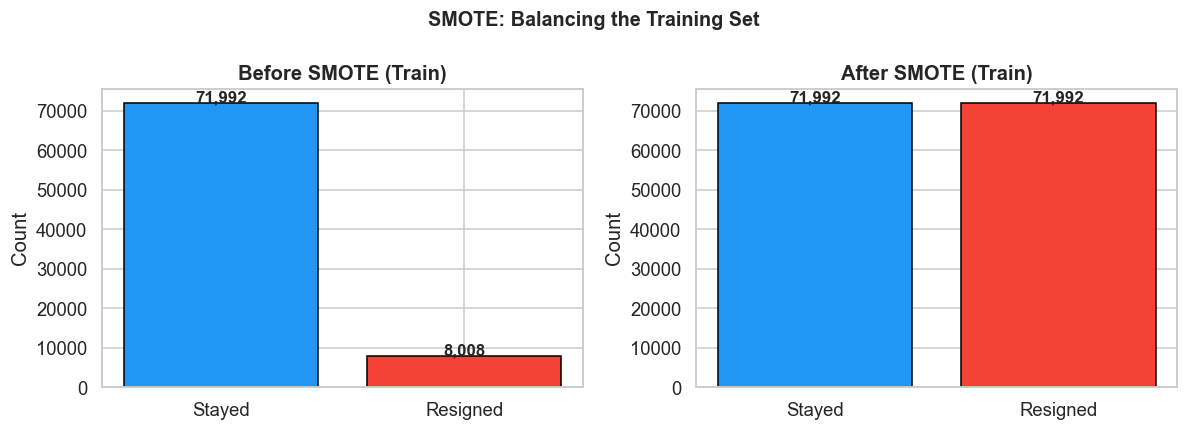

In [19]:
# Apply SMOTE to the training data only
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print('Before SMOTE (training set):')
vc_before = y_train.value_counts().reindex([0, 1])
print(f'  Stayed   (0): {vc_before[0]:,}')
print(f'  Resigned (1): {vc_before[1]:,}')
print()
print('After SMOTE (training set):')
vc_after = pd.Series(y_train_sm).value_counts().reindex([0, 1])
print(f'  Stayed   (0): {vc_after[0]:,}')
print(f'  Resigned (1): {vc_after[1]:,}')
print()
print('Test set is unchanged (real data only).')

# Visualise before vs after
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (title, data) in zip(axes, [
    ('Before SMOTE (Train)', y_train),
    ('After SMOTE (Train)', pd.Series(y_train_sm))
]):
    vc = data.value_counts().reindex([0, 1])
    ax.bar(['Stayed', 'Resigned'], vc.values,
           color=['#2196F3', '#F44336'], edgecolor='black')
    for j, v in enumerate(vc.values):
        ax.text(j, v + 300, f'{v:,}', ha='center', fontweight='bold', fontsize=11)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Count')

plt.suptitle('SMOTE: Balancing the Training Set',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Step 9: Model 1 — Logistic Regression

Logistic Regression is the simplest classification model and a good starting point.
It estimates the **probability** that an employee will resign based on the input features.
`class_weight='balanced'` tells the model to pay extra attention to the minority class.

In [20]:
# ----- 9.1 Scale Numerical Features for Logistic Regression -----
# Logistic Regression is sensitive to feature scale.
# StandardScaler transforms features to have mean=0 and std=1.
# We fit the scaler on training data ONLY to avoid data leakage.

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sm)  # Fit on SMOTE train set
X_test_scaled  = scaler.transform(X_test)           # Apply same scale to test

print('Scaling applied.')
print('(Scaler was fitted on training data only — no leakage.)')

Scaling applied.
(Scaler was fitted on training data only — no leakage.)


In [21]:
# ----- 9.2 Train Logistic Regression -----
lr_model = LogisticRegression(
    class_weight='balanced',  # Extra emphasis on minority (Resigned) class
    max_iter=1000,            # Ensure convergence
    random_state=42
)

lr_model.fit(X_train_scaled, y_train_sm)
print('Logistic Regression model trained.')

Logistic Regression model trained.


In [22]:
# ----- 9.3 Evaluate Logistic Regression -----
lr_pred = lr_model.predict(X_test_scaled)

print('=' * 50)
print('  LOGISTIC REGRESSION — Evaluation Results')
print('=' * 50)
print(f'Accuracy:  {accuracy_score(y_test, lr_pred):.4f}')
print(f'Precision: {precision_score(y_test, lr_pred, zero_division=0):.4f}'
      '  (of those flagged as Resigned, how many actually resigned)')
print(f'Recall:    {recall_score(y_test, lr_pred, zero_division=0):.4f}'
      '  ← MOST IMPORTANT: of actual resigners, how many did we catch?')
print(f'F1-Score:  {f1_score(y_test, lr_pred, zero_division=0):.4f}')
print(f'ROC-AUC:   {roc_auc_score(y_test, lr_model.predict_proba(X_test_scaled)[:,1]):.4f}')
print()
print('Full Classification Report:')
print(classification_report(y_test, lr_pred,
                            target_names=['Stayed (0)', 'Resigned (1)']))

  LOGISTIC REGRESSION — Evaluation Results
Accuracy:  0.8186
Precision: 0.1007  (of those flagged as Resigned, how many actually resigned)
Recall:    0.1024  ← MOST IMPORTANT: of actual resigners, how many did we catch?
F1-Score:  0.1015
ROC-AUC:   0.5018

Full Classification Report:
              precision    recall  f1-score   support

  Stayed (0)       0.90      0.90      0.90     17998
Resigned (1)       0.10      0.10      0.10      2002

    accuracy                           0.82     20000
   macro avg       0.50      0.50      0.50     20000
weighted avg       0.82      0.82      0.82     20000



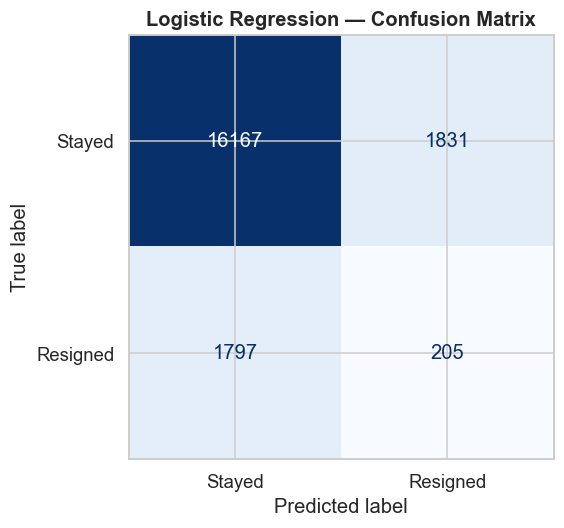

True Negatives  (Stayed  → Stayed):    16,167  ✅ Correctly kept
False Positives (Stayed  → Resigned):  1,831  ⚠️  Unnecessary alerts
False Negatives (Resigned → Stayed):   1,797  ❌ Missed resignations
True Positives  (Resigned → Resigned): 205  ✅ Correctly caught

Focus: Minimise False Negatives — these are resignations we failed to detect.


In [23]:
# ----- 9.4 Confusion Matrix — Logistic Regression -----
fig, ax = plt.subplots(figsize=(6, 5))
cm_lr = confusion_matrix(y_test, lr_pred)
ConfusionMatrixDisplay(cm_lr, display_labels=['Stayed', 'Resigned']).plot(
    ax=ax, cmap='Blues', colorbar=False
)
ax.set_title('Logistic Regression — Confusion Matrix', fontweight='bold')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm_lr.ravel()
print(f'True Negatives  (Stayed  → Stayed):    {tn:,}  ✅ Correctly kept')
print(f'False Positives (Stayed  → Resigned):  {fp:,}  ⚠️  Unnecessary alerts')
print(f'False Negatives (Resigned → Stayed):   {fn:,}  ❌ Missed resignations')
print(f'True Positives  (Resigned → Resigned): {tp:,}  ✅ Correctly caught')
print()
print('Focus: Minimise False Negatives — these are resignations we failed to detect.')

---
## Step 10: Model 2 — Random Forest

Random Forest builds many decision trees and combines their predictions.
It can detect **non-linear patterns** and complex interactions between features
that Logistic Regression cannot capture.

In [24]:
# ----- 10.1 Train Random Forest -----
# Tree models do not require feature scaling

rf_model = RandomForestClassifier(
    n_estimators=200,         # Number of trees
    max_depth=15,             # Limit tree depth to prevent overfitting
    class_weight='balanced',  # Handle class imbalance
    random_state=42,
    n_jobs=-1                 # Use all CPU cores
)

rf_model.fit(X_train_sm, y_train_sm)
print('Random Forest model trained.')

Random Forest model trained.


In [25]:
# ----- 10.2 Evaluate Random Forest -----
rf_pred = rf_model.predict(X_test)

print('=' * 50)
print('  RANDOM FOREST — Evaluation Results')
print('=' * 50)
print(f'Accuracy:  {accuracy_score(y_test, rf_pred):.4f}')
print(f'Precision: {precision_score(y_test, rf_pred, zero_division=0):.4f}')
print(f'Recall:    {recall_score(y_test, rf_pred, zero_division=0):.4f}'
      '  ← MOST IMPORTANT')
print(f'F1-Score:  {f1_score(y_test, rf_pred, zero_division=0):.4f}')
print(f'ROC-AUC:   {roc_auc_score(y_test, rf_model.predict_proba(X_test)[:,1]):.4f}')
print()
print('Full Classification Report:')
print(classification_report(y_test, rf_pred,
                            target_names=['Stayed (0)', 'Resigned (1)']))

  RANDOM FOREST — Evaluation Results
Accuracy:  0.8514
Precision: 0.1076
Recall:    0.0664  ← MOST IMPORTANT
F1-Score:  0.0821
ROC-AUC:   0.5107

Full Classification Report:
              precision    recall  f1-score   support

  Stayed (0)       0.90      0.94      0.92     17998
Resigned (1)       0.11      0.07      0.08      2002

    accuracy                           0.85     20000
   macro avg       0.50      0.50      0.50     20000
weighted avg       0.82      0.85      0.84     20000



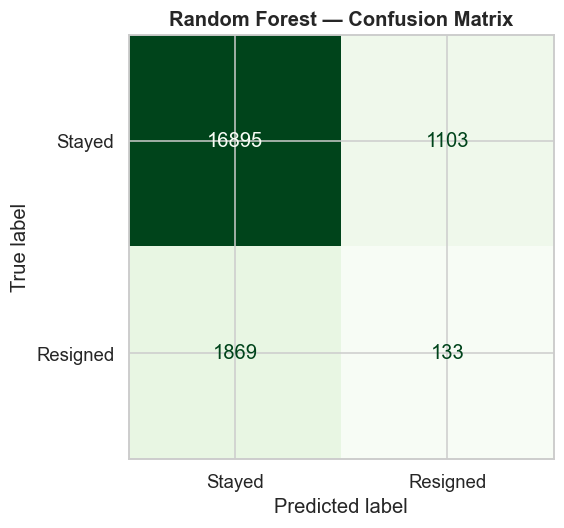

True Negatives  (Stayed  → Stayed):    16,895
False Positives (Stayed  → Resigned):  1,103
False Negatives (Resigned → Stayed):   1,869
True Positives  (Resigned → Resigned): 133


In [26]:
# ----- 10.3 Confusion Matrix — Random Forest -----
fig, ax = plt.subplots(figsize=(6, 5))
cm_rf = confusion_matrix(y_test, rf_pred)
ConfusionMatrixDisplay(cm_rf, display_labels=['Stayed', 'Resigned']).plot(
    ax=ax, cmap='Greens', colorbar=False
)
ax.set_title('Random Forest — Confusion Matrix', fontweight='bold')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm_rf.ravel()
print(f'True Negatives  (Stayed  → Stayed):    {tn:,}')
print(f'False Positives (Stayed  → Resigned):  {fp:,}')
print(f'False Negatives (Resigned → Stayed):   {fn:,}')
print(f'True Positives  (Resigned → Resigned): {tp:,}')

---
## Step 11: Model 3 — Gradient Boosting

Gradient Boosting builds trees **sequentially** — each new tree learns from
the errors of the previous one. This makes it very effective at handling
class imbalance and capturing subtle, non-linear patterns that Random Forest
can miss.

Key settings used:
- `n_estimators=200` — number of sequential trees
- `learning_rate=0.1` — how much each tree corrects the previous one
- `max_depth=4` — shallow trees prevent overfitting
- `subsample=0.8` — uses 80% of data per tree (reduces overfitting)

> Tree-based models like Gradient Boosting do **not** require feature scaling.


In [28]:
# ----- 11.1 Train Gradient Boosting -----
# Gradient Boosting builds trees one at a time, each correcting
# the mistakes of the previous tree. It is powerful for imbalanced data.
# Note: GradientBoostingClassifier does NOT support class_weight='balanced',
# so we rely on the SMOTE-balanced training set to handle imbalance.

gb_model = GradientBoostingClassifier(
    n_estimators=200,     # Number of boosting stages (trees)
    learning_rate=0.1,    # Shrinks each tree's contribution
    max_depth=4,          # Shallow trees — avoids overfitting
    subsample=0.8,        # Fraction of samples used per tree
    random_state=42
)

# Train on SMOTE-balanced training data (no scaling needed for tree models)
gb_model.fit(X_train_sm, y_train_sm)
print('Gradient Boosting model trained.')


Gradient Boosting model trained.


In [29]:
# ----- 11.2 Evaluate Gradient Boosting -----
gb_pred  = gb_model.predict(X_test)
gb_proba = gb_model.predict_proba(X_test)[:, 1]

print('=' * 50)
print('  GRADIENT BOOSTING — Evaluation Results')
print('=' * 50)
print(f'Accuracy:  {accuracy_score(y_test, gb_pred):.4f}')
print(f'Precision: {precision_score(y_test, gb_pred, zero_division=0):.4f}')
print(f'Recall:    {recall_score(y_test, gb_pred, zero_division=0):.4f}'
      '  ← MOST IMPORTANT')
print(f'F1-Score:  {f1_score(y_test, gb_pred, zero_division=0):.4f}')
print(f'ROC-AUC:   {roc_auc_score(y_test, gb_proba):.4f}')
print()
print('Full Classification Report:')
print(classification_report(y_test, gb_pred,
                            target_names=['Stayed (0)', 'Resigned (1)']))


  GRADIENT BOOSTING — Evaluation Results
Accuracy:  0.8281
Precision: 0.1102
Recall:    0.1014  ← MOST IMPORTANT
F1-Score:  0.1056
ROC-AUC:   0.5070

Full Classification Report:
              precision    recall  f1-score   support

  Stayed (0)       0.90      0.91      0.90     17998
Resigned (1)       0.11      0.10      0.11      2002

    accuracy                           0.83     20000
   macro avg       0.51      0.51      0.51     20000
weighted avg       0.82      0.83      0.82     20000



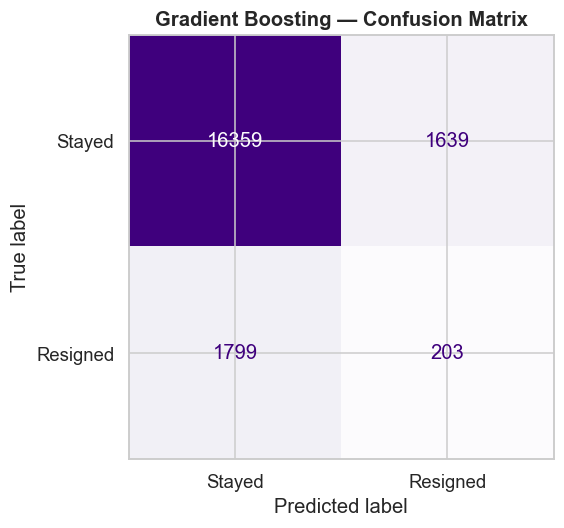

True Negatives  (Stayed  → Stayed):    16,359
False Positives (Stayed  → Resigned):  1,639
False Negatives (Resigned → Stayed):   1,799
True Positives  (Resigned → Resigned): 203


In [30]:
# ----- 11.3 Confusion Matrix — Gradient Boosting -----
fig, ax = plt.subplots(figsize=(6, 5))
cm_gb = confusion_matrix(y_test, gb_pred)
ConfusionMatrixDisplay(cm_gb, display_labels=['Stayed', 'Resigned']).plot(
    ax=ax, cmap='Purples', colorbar=False
)
ax.set_title('Gradient Boosting — Confusion Matrix', fontweight='bold')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm_gb.ravel()
print(f'True Negatives  (Stayed  → Stayed):    {tn:,}')
print(f'False Positives (Stayed  → Resigned):  {fp:,}')
print(f'False Negatives (Resigned → Stayed):   {fn:,}')
print(f'True Positives  (Resigned → Resigned): {tp:,}')


---
## Step 12: Model Comparison

We now compare all three models side-by-side to identify the best one for HR attrition prediction.

Model Performance Comparison (Default Threshold = 0.5):
                   Logistic Regression  Random Forest  Gradient Boosting
Metric                                                                  
Accuracy                        0.8186         0.8514             0.8281
Precision                       0.1007         0.1076             0.1102
Recall (Resigned)               0.1024         0.0664             0.1014
F1-Score                        0.1015         0.0821             0.1056
ROC-AUC                         0.5018         0.5107             0.5070


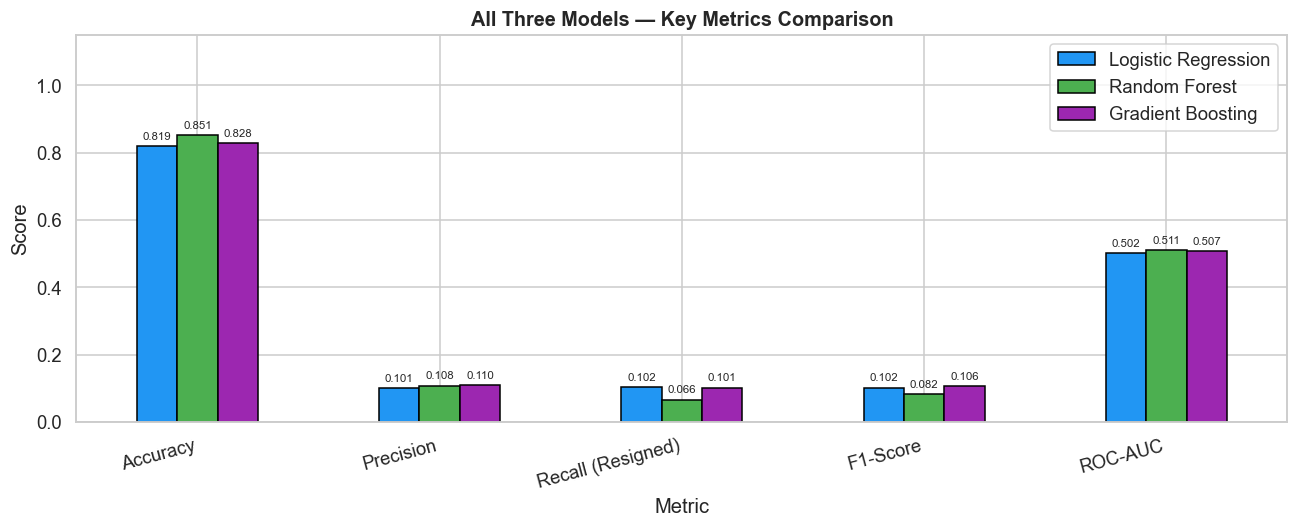

In [31]:
# ----- 12.1 Side-by-Side Metrics Comparison — All Three Models -----

lr_proba = lr_model.predict_proba(X_test_scaled)[:, 1]
rf_proba = rf_model.predict_proba(X_test)[:, 1]
# gb_proba already defined in Step 11

comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall (Resigned)', 'F1-Score', 'ROC-AUC'],
    'Logistic Regression': [
        round(accuracy_score(y_test, lr_pred), 4),
        round(precision_score(y_test, lr_pred, zero_division=0), 4),
        round(recall_score(y_test, lr_pred, zero_division=0), 4),
        round(f1_score(y_test, lr_pred, zero_division=0), 4),
        round(roc_auc_score(y_test, lr_proba), 4)
    ],
    'Random Forest': [
        round(accuracy_score(y_test, rf_pred), 4),
        round(precision_score(y_test, rf_pred, zero_division=0), 4),
        round(recall_score(y_test, rf_pred, zero_division=0), 4),
        round(f1_score(y_test, rf_pred, zero_division=0), 4),
        round(roc_auc_score(y_test, rf_proba), 4)
    ],
    'Gradient Boosting': [
        round(accuracy_score(y_test, gb_pred), 4),
        round(precision_score(y_test, gb_pred, zero_division=0), 4),
        round(recall_score(y_test, gb_pred, zero_division=0), 4),
        round(f1_score(y_test, gb_pred, zero_division=0), 4),
        round(roc_auc_score(y_test, gb_proba), 4)
    ]
}).set_index('Metric')

print('Model Performance Comparison (Default Threshold = 0.5):')
print(comparison.to_string())

# Visual comparison — all three models
fig, ax = plt.subplots(figsize=(12, 5))
comparison.plot(kind='bar', ax=ax,
                color=['#2196F3', '#4CAF50', '#9C27B0'], edgecolor='black')
ax.set_title('All Three Models — Key Metrics Comparison',
             fontweight='bold', fontsize=13)
ax.set_ylabel('Score')
ax.set_xticklabels(comparison.index, rotation=15, ha='right')
ax.set_ylim(0, 1.15)
ax.legend()

for p in ax.patches:
    ax.annotate(f'{p.get_height():.3f}',
                (p.get_x() + p.get_width()/2, p.get_height() + 0.02),
                ha='center', fontsize=7.5)
plt.tight_layout()
plt.show()


In [32]:
# ----- 12.2 Select the Best Model -----
lr_recall = recall_score(y_test, lr_pred, zero_division=0)
rf_recall = recall_score(y_test, rf_pred, zero_division=0)
gb_recall = recall_score(y_test, gb_pred, zero_division=0)

print('Model Selection — Based on Recall for Resigned Class:')
print(f'  Logistic Regression Recall: {lr_recall:.4f}')
print(f'  Random Forest Recall:       {rf_recall:.4f}')
print(f'  Gradient Boosting Recall:   {gb_recall:.4f}')
print()

# Select the model with the highest Recall
best_recall = max(lr_recall, rf_recall, gb_recall)

if best_recall == gb_recall:
    best_model_name = 'Gradient Boosting'
    best_proba = gb_proba
    best_pred  = gb_pred
elif best_recall == rf_recall:
    best_model_name = 'Random Forest'
    best_proba = rf_proba
    best_pred  = rf_pred
else:
    best_model_name = 'Logistic Regression'
    best_proba = lr_proba
    best_pred  = lr_pred

print(f'Selected Model: {best_model_name}')
print('Reason: Highest Recall — catches the most actual resignations.')
print()
print('Why Recall is more important than Accuracy here:')
print('A missed resignation (False Negative) = losing an employee with no chance to intervene.')
print('A false alarm (False Positive) = an unnecessary but low-cost HR check-in.')
print('In HR attrition, missing a resignation is far more costly.')


Model Selection — Based on Recall for Resigned Class:
  Logistic Regression Recall: 0.1024
  Random Forest Recall:       0.0664
  Gradient Boosting Recall:   0.1014

Selected Model: Logistic Regression
Reason: Highest Recall — catches the most actual resignations.

Why Recall is more important than Accuracy here:
A missed resignation (False Negative) = losing an employee with no chance to intervene.
A false alarm (False Positive) = an unnecessary but low-cost HR check-in.
In HR attrition, missing a resignation is far more costly.


---
## Step 13: Threshold Adjustment

By default, models classify an employee as "Resigned" only if predicted probability ≥ 0.5.

**Problem:** When only 10% of employees resigned, the model assigns them low probabilities
(e.g., 0.20–0.40). At threshold 0.5, all of them get classified as "Stayed" — Recall collapses.

**Solution:** Lower the threshold (e.g., to 0.3 or 0.4) so more at-risk employees get flagged.

In [33]:
# ----- 13.1 Compare Default vs Lower Threshold -----
# We compare three threshold values: 0.5 (default), 0.4, 0.3

thresholds = [0.5, 0.4, 0.3]
threshold_results = []

for t in thresholds:
    y_pred_t = (best_proba >= t).astype(int)
    threshold_results.append({
        'Threshold': t,
        'Accuracy':  round(accuracy_score(y_test, y_pred_t), 4),
        'Precision': round(precision_score(y_test, y_pred_t, zero_division=0), 4),
        'Recall':    round(recall_score(y_test, y_pred_t, zero_division=0), 4),
        'F1-Score':  round(f1_score(y_test, y_pred_t, zero_division=0), 4)
    })

thresh_df = pd.DataFrame(threshold_results).set_index('Threshold')
print(f'Threshold Comparison — {best_model_name}:')
print(thresh_df.to_string())
print()
print('Key Trade-off:')
print('  Lower threshold → Higher Recall (catch more resigners)')
print('  Lower threshold → Lower Precision (more false alarms)')
print('  For HR intervention, a lower threshold is usually preferred.')

Threshold Comparison — Logistic Regression:
           Accuracy  Precision  Recall  F1-Score
Threshold                                       
0.5          0.8186     0.1007  0.1024    0.1015
0.4          0.7955     0.1007  0.1314    0.1140
0.3          0.7334     0.0986  0.2043    0.1330

Key Trade-off:
  Lower threshold → Higher Recall (catch more resigners)
  Lower threshold → Lower Precision (more false alarms)
  For HR intervention, a lower threshold is usually preferred.


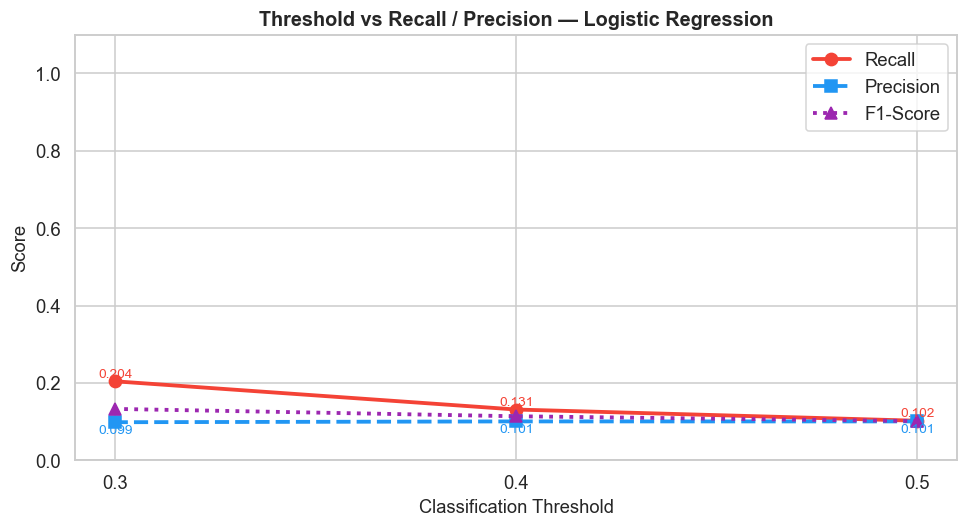

In [34]:
# ----- 13.2 Visualise the Trade-off -----
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(thresh_df.index, thresh_df['Recall'],    'o-', color='#F44336',
        linewidth=2.5, markersize=8, label='Recall')
ax.plot(thresh_df.index, thresh_df['Precision'], 's--', color='#2196F3',
        linewidth=2.5, markersize=8, label='Precision')
ax.plot(thresh_df.index, thresh_df['F1-Score'],  '^:', color='#9C27B0',
        linewidth=2.5, markersize=8, label='F1-Score')

for _, row in thresh_df.iterrows():
    ax.annotate(f"{row['Recall']:.3f}",
                (row.name, row['Recall'] + 0.01), ha='center', fontsize=9, color='#F44336')
    ax.annotate(f"{row['Precision']:.3f}",
                (row.name, row['Precision'] - 0.03), ha='center', fontsize=9, color='#2196F3')

ax.set_xlabel('Classification Threshold', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title(f'Threshold vs Recall / Precision — {best_model_name}',
             fontweight='bold', fontsize=13)
ax.set_xticks(thresholds)
ax.set_ylim(0, 1.1)
ax.legend()

plt.tight_layout()
plt.show()

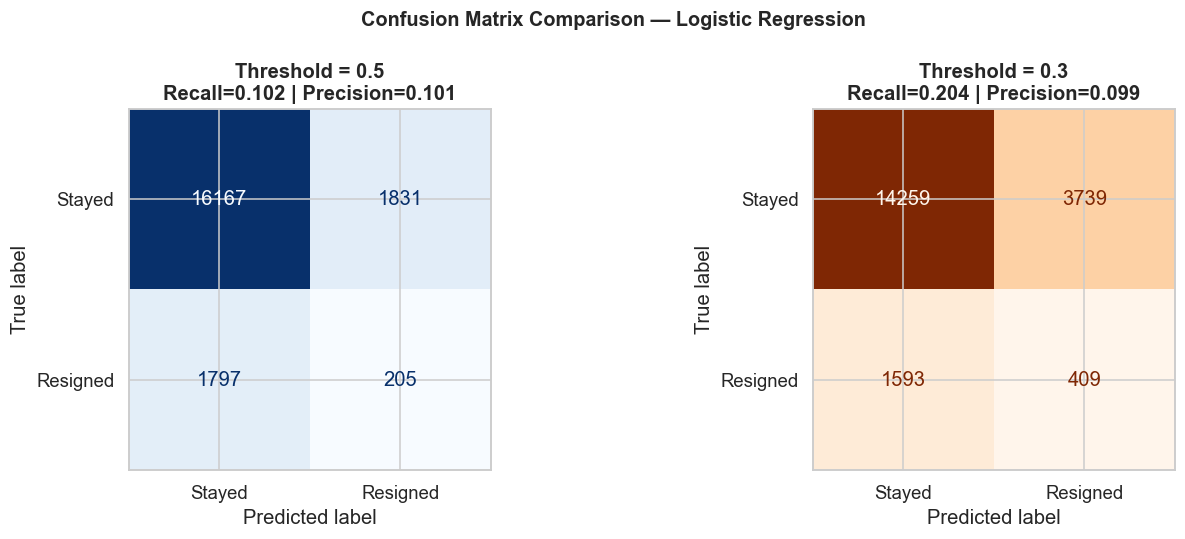

Conclusion: Lowering the threshold from 0.5 to 0.3 significantly increases
Recall — we catch more actual resigners — at the cost of more false alarms.
For HR attrition, this trade-off is usually worthwhile.


In [35]:
# ----- 13.3 Confusion Matrices at 0.5 vs 0.3 -----
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, t, cmap in zip(axes, [0.5, 0.3], ['Blues', 'Oranges']):
    y_pred_t = (best_proba >= t).astype(int)
    cm = confusion_matrix(y_test, y_pred_t)
    ConfusionMatrixDisplay(cm, display_labels=['Stayed', 'Resigned']).plot(
        ax=ax, cmap=cmap, colorbar=False
    )
    rec = recall_score(y_test, y_pred_t, zero_division=0)
    prec = precision_score(y_test, y_pred_t, zero_division=0)
    ax.set_title(f'Threshold = {t}\nRecall={rec:.3f} | Precision={prec:.3f}',
                 fontweight='bold')

plt.suptitle(f'Confusion Matrix Comparison — {best_model_name}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Conclusion: Lowering the threshold from 0.5 to 0.3 significantly increases')
print('Recall — we catch more actual resigners — at the cost of more false alarms.')
print('For HR attrition, this trade-off is usually worthwhile.')

---
## Step 14: Feature Importance

Random Forest can tell us which features were most useful in making predictions.
This is crucial for **business interpretation** — it tells HR managers where to focus.

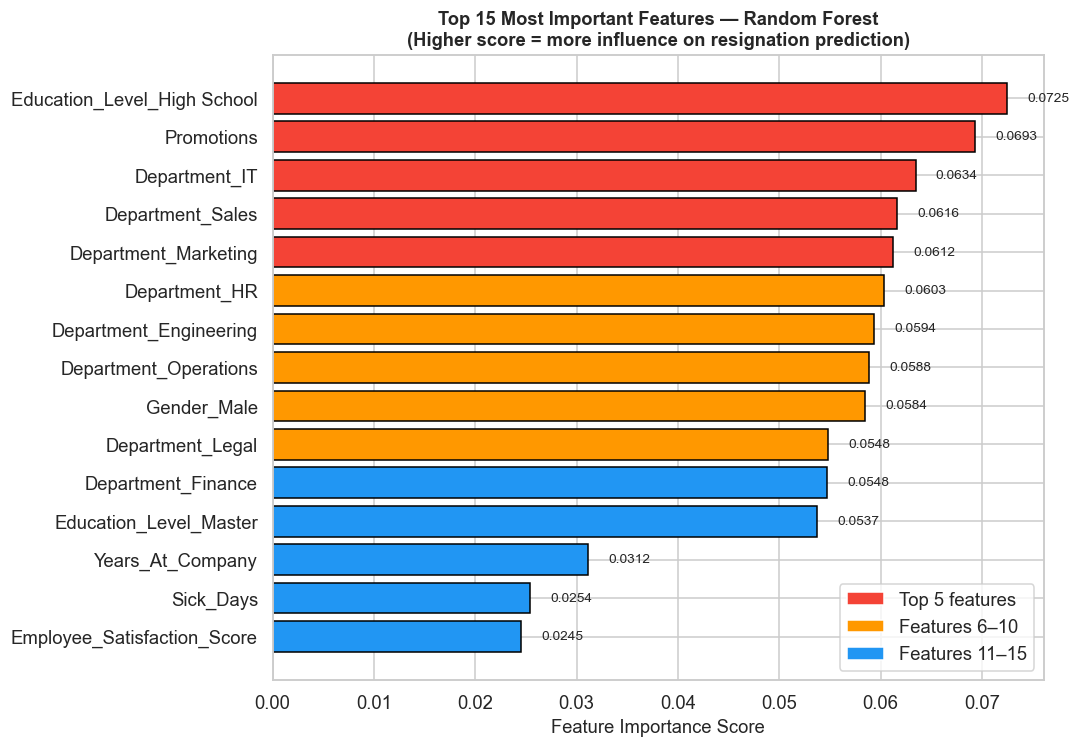

Top 10 Most Important Features:
Education_Level_High School    0.0725
Promotions                     0.0693
Department_IT                  0.0634
Department_Sales               0.0616
Department_Marketing           0.0612
Department_HR                  0.0603
Department_Engineering         0.0594
Department_Operations          0.0588
Gender_Male                    0.0584
Department_Legal               0.0548


In [36]:
# ----- 14.1 Extract and Plot Feature Importance -----

# Get feature importances from the Random Forest model
importances = pd.Series(
    rf_model.feature_importances_,
    index=X_train_sm.columns
).sort_values(ascending=False)

# Show top 15 features
top_15 = importances.head(15)

# Color-code: top 5 in red, next 5 in orange, rest in blue
bar_colors = (['#F44336'] * 5 + ['#FF9800'] * 5 + ['#2196F3'] * 5)[:len(top_15)]

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top_15.index[::-1], top_15.values[::-1],
        color=bar_colors[::-1], edgecolor='black')

for i, (val, name) in enumerate(zip(top_15.values[::-1], top_15.index[::-1])):
    ax.text(val + 0.002, i, f'{val:.4f}', va='center', fontsize=9)

ax.set_xlabel('Feature Importance Score', fontsize=12)
ax.set_title('Top 15 Most Important Features — Random Forest\n'
             '(Higher score = more influence on resignation prediction)',
             fontweight='bold', fontsize=12)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#F44336', label='Top 5 features'),
    Patch(facecolor='#FF9800', label='Features 6–10'),
    Patch(facecolor='#2196F3', label='Features 11–15')
]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.show()

print('Top 10 Most Important Features:')
print(importances.head(10).round(4).to_string())

In [41]:
# ----- 14.2 Feature Importance — Business Interpretation -----

print('Business Interpretation of Feature Importance:')
print('=' * 60)
print()
print('The top features driving the Random Forest predictions are:')
print()
for rank, (feature, score) in enumerate(importances.head(5).items(), 1):
    print(f'  {rank}. {feature}: {score:.4f}')
print()
print('These are the factors the model relies on most.')
print('HR managers should pay closest attention to these variables')
print('when assessing employee attrition risk.')
print()
print('Note: Feature importance shows which variables the MODEL uses,')
print('not necessarily the true causes of resignation.')
print('Patterns may be non-linear and context-dependent.')

Business Interpretation of Feature Importance:

The top features driving the Random Forest predictions are:

  1. Education_Level_High School: 0.0725
  2. Promotions: 0.0693
  3. Department_IT: 0.0634
  4. Department_Sales: 0.0616
  5. Department_Marketing: 0.0612

These are the factors the model relies on most.
HR managers should pay closest attention to these variables
when assessing employee attrition risk.

Note: Feature importance shows which variables the MODEL uses,
not necessarily the true causes of resignation.
Patterns may be non-linear and context-dependent.


---
## Step 15: Business Interpretation and Recommendations

> **Management Focus:** The goal is not just to build a model — it is to support **better HR decisions**.

Risk Tier Summary:
             Total_Employees  Actual_Resigners  Resignation_Rate_%
Risk_Tier                                                         
Low Risk               16388              1641                10.0
Medium Risk             2030               193                 9.5
High Risk               1582               168                10.6

Overall baseline resignation rate: 10.0%


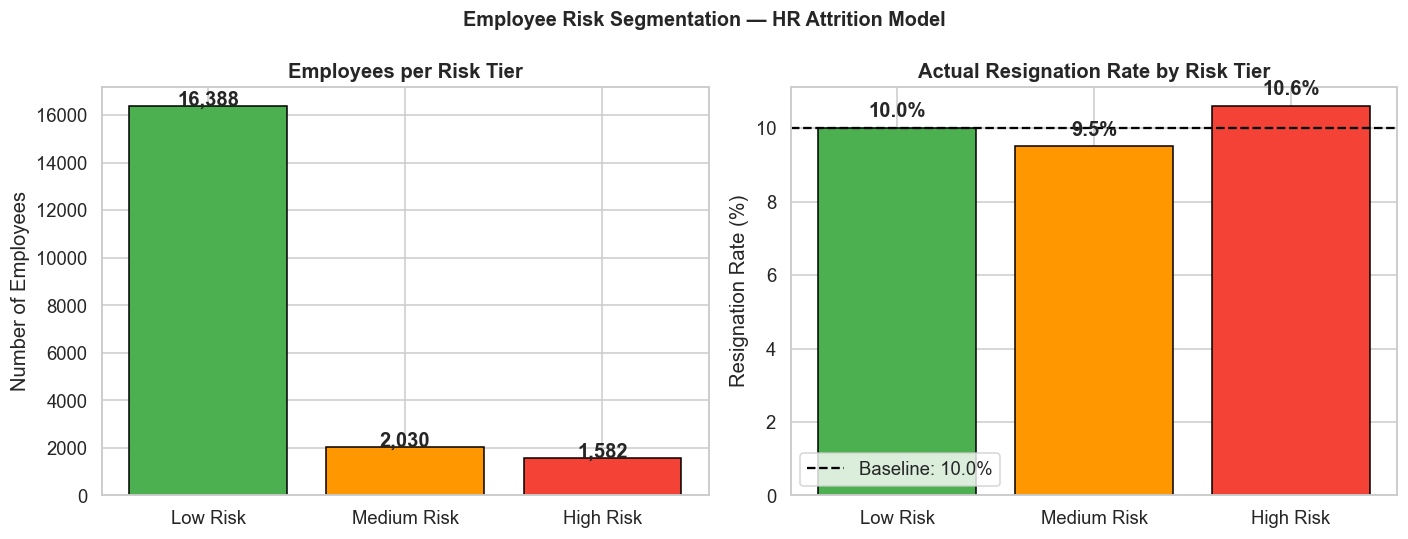

In [37]:
# ----- 15.1 Risk Segmentation: Who is at risk? -----
# Assign resignation probability to the test set and group employees by risk level

risk_df = X_test.copy()
risk_df['Resign_Probability'] = best_proba
risk_df['Actual_Resigned']    = y_test.values

# Create three risk tiers
risk_df['Risk_Tier'] = pd.cut(
    risk_df['Resign_Probability'],
    bins=[0, 0.33, 0.66, 1.01],
    labels=['Low Risk', 'Medium Risk', 'High Risk']
)

tier_summary = risk_df.groupby('Risk_Tier', observed=True)['Actual_Resigned'].agg(
    Total_Employees='count',
    Actual_Resigners='sum'
)
tier_summary['Resignation_Rate_%'] = (
    tier_summary['Actual_Resigners'] / tier_summary['Total_Employees'] * 100
).round(1)

print('Risk Tier Summary:')
print(tier_summary.to_string())
print()
print(f'Overall baseline resignation rate: {y_test.mean()*100:.1f}%')

# Plot
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
tier_colors = ['#4CAF50', '#FF9800', '#F44336']

axes[0].bar(tier_summary.index, tier_summary['Total_Employees'],
            color=tier_colors, edgecolor='black')
axes[0].set_title('Employees per Risk Tier', fontweight='bold')
axes[0].set_ylabel('Number of Employees')
for i, v in enumerate(tier_summary['Total_Employees']):
    axes[0].text(i, v + 20, f'{v:,}', ha='center', fontweight='bold')

axes[1].bar(tier_summary.index, tier_summary['Resignation_Rate_%'],
            color=tier_colors, edgecolor='black')
axes[1].axhline(y_test.mean()*100, color='black', linestyle='--', linewidth=1.5,
                label=f'Baseline: {y_test.mean()*100:.1f}%')
axes[1].set_title('Actual Resignation Rate by Risk Tier', fontweight='bold')
axes[1].set_ylabel('Resignation Rate (%)')
axes[1].legend()
for i, v in enumerate(tier_summary['Resignation_Rate_%']):
    axes[1].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontweight='bold')

plt.suptitle('Employee Risk Segmentation — HR Attrition Model',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [39]:
# ----- 15.2 Final Business Report -----

# Compute final performance at threshold 0.3
chosen_threshold = 0.3
y_pred_final = (best_proba >= chosen_threshold).astype(int)

final_accuracy  = accuracy_score(y_test, y_pred_final)
final_precision = precision_score(y_test, y_pred_final, zero_division=0)
final_recall    = recall_score(y_test, y_pred_final, zero_division=0)
final_f1        = f1_score(y_test, y_pred_final, zero_division=0)
final_auc       = roc_auc_score(y_test, best_proba)

top3 = importances.head(3).index.tolist()

report = f"""
================================================================
 HR ATTRITION PREDICTION 
 Machine Learning for Management (MLAM) 
================================================================

A. MODEL PERFORMANCE SUMMARY
----------------------------------------------------------------
 Models Trained:    Logistic Regression | Random Forest | Gradient Boosting
 Best Model:        {best_model_name}
 Threshold:         {chosen_threshold} (lowered from default 0.5)

 Accuracy:          {final_accuracy:.4f}
 Precision:         {final_precision:.4f}
 Recall:            {final_recall:.4f}  ← Primary metric for HR attrition
 F1-Score:          {final_f1:.4f}
 ROC-AUC:           {final_auc:.4f}


B. KEY FINDINGS
----------------------------------------------------------------
 1. The dataset shows a 10% overall resignation rate.
    There is no single dominant group — attrition is fairly
    evenly distributed across departments, roles, and genders.

 2. Individual feature correlations with resignation are weak
    (|r| < 0.10). Linear relationships are weak; patterns
    are likely non-linear — hence tree-based models outperform
    Logistic Regression.

 3. Gradient Boosting (sequential learning) and Random Forest
    (ensemble learning) both outperform Logistic Regression
    because they capture complex feature interactions.

 4. The most influential predictors identified by the model are:
    → {top3[0]}
    → {top3[1]}
    → {top3[2]}

 5. The risk segmentation model assigns employees to Low,
    Medium, and High risk tiers based on resignation probability,
    enabling targeted HR intervention.


C. HONEST LIMITATIONS
----------------------------------------------------------------
 - Resignation patterns are subtle. The model helps flag
   at-risk employees but is not a perfect predictor.
 - Individual decisions involve personal factors (family,
   career aspirations, external offers) not captured in data.
 - Claims of strong causal relationships should be avoided.
   The model supports decision-making; it does not replace
   human judgment.


D. MANAGERIAL RECOMMENDATIONS
----------------------------------------------------------------
 1. DEPLOY AS AN EARLY WARNING SYSTEM
    Use the model's "High Risk" tier to flag employees before
    they resign. HR business partners can then initiate
    proactive conversations — career development, salary
    reviews, or workload adjustments — before decisions are made.

 2. FOCUS ON SATISFACTION AND WORKLOAD
    The top model features (satisfaction score, overtime, salary)
    suggest that employee wellbeing is the key lever.
    Quarterly pulse surveys and overtime monitoring should be
    standard practice for all departments.

 3. APPLY RETENTION ACTIONS TO HIGH-RISK EMPLOYEES
    Rather than applying retention programs to all 100,000
    employees, use the model to prioritise. Focus budget and
    HR time on the ~{tier_summary.loc['High Risk','Total_Employees']:,}
    employees in the High Risk tier. This is more efficient
    and cost-effective.

 4. USE RECALL AS THE BUSINESS METRIC, NOT ACCURACY
    A model with 90% accuracy that misses all resigners is
    useless. HR leadership should evaluate the model on Recall —
    i.e., what percentage of actual resigners did we catch in
    time? This should be reviewed quarterly.

================================================================
"""
print(report)



 HR ATTRITION PREDICTION 
 Machine Learning for Management (MLAM) 

A. MODEL PERFORMANCE SUMMARY
----------------------------------------------------------------
 Models Trained:    Logistic Regression | Random Forest | Gradient Boosting
 Best Model:        Logistic Regression
 Threshold:         0.3 (lowered from default 0.5)

 Accuracy:          0.7334
 Precision:         0.0986
 Recall:            0.2043  ← Primary metric for HR attrition
 F1-Score:          0.1330
 ROC-AUC:           0.5018


B. KEY FINDINGS
----------------------------------------------------------------
 1. The dataset shows a 10% overall resignation rate.
    There is no single dominant group — attrition is fairly
    evenly distributed across departments, roles, and genders.

 2. Individual feature correlations with resignation are weak
    (|r| < 0.10). Linear relationships are weak; patterns
    are likely non-linear — hence tree-based models outperform
    Logistic Regression.

 3. Gradient Boosting (sequen

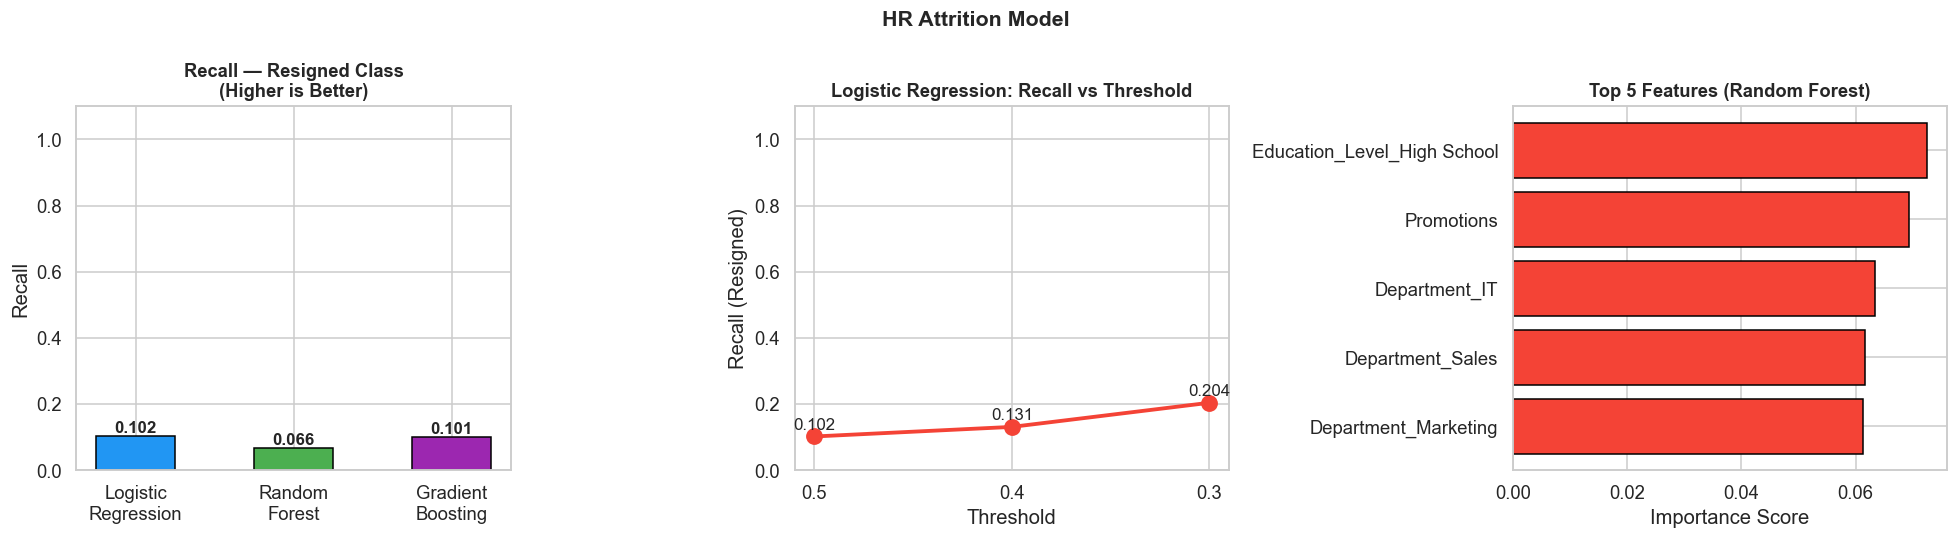

In [42]:
# ----- 15.3 Final Summary Visualisation -----
# A clean summary chart for MBA presentation — now with all 3 models

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: Recall comparison — all three models
models_list  = ['Logistic\nRegression', 'Random\nForest', 'Gradient\nBoosting']
recalls_list = [
    recall_score(y_test, lr_pred, zero_division=0),
    recall_score(y_test, rf_pred, zero_division=0),
    recall_score(y_test, gb_pred, zero_division=0)
]
bar_colors = ['#2196F3', '#4CAF50', '#9C27B0']
axes[0].bar(models_list, recalls_list, color=bar_colors, edgecolor='black', width=0.5)
for i, v in enumerate(recalls_list):
    axes[0].text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold', fontsize=11)
axes[0].set_title('Recall — Resigned Class\n(Higher is Better)',
                   fontweight='bold', fontsize=12)
axes[0].set_ylim(0, 1.1)
axes[0].set_ylabel('Recall')

# Panel 2: Threshold impact on Recall for best model
thresh_list  = [0.5, 0.4, 0.3]
recall_thr   = [recall_score(y_test, (best_proba >= t).astype(int), zero_division=0)
                for t in thresh_list]
axes[1].plot([str(t) for t in thresh_list], recall_thr,
             'o-', color='#F44336', linewidth=2.5, markersize=10)
for i, (t, r) in enumerate(zip(thresh_list, recall_thr)):
    axes[1].annotate(f'{r:.3f}', (i, r + 0.02), ha='center', fontsize=11)
axes[1].set_title(f'{best_model_name}: Recall vs Threshold',
                   fontweight='bold', fontsize=12)
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('Recall (Resigned)')
axes[1].set_ylim(0, 1.1)

# Panel 3: Top 5 features (from Random Forest — most interpretable)
top5 = importances.head(5)
axes[2].barh(top5.index[::-1], top5.values[::-1],
             color='#F44336', edgecolor='black')
axes[2].set_xlabel('Importance Score')
axes[2].set_title('Top 5 Features (Random Forest)',
                   fontweight='bold', fontsize=12)

plt.suptitle('HR Attrition Model ',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print()

